# Assignment 6

### <span style="color:chocolate"> Submission requirements </span>

Your work will not be graded if your notebook doesn't include output. In other words, <span style="color:red"> make sure to rerun your notebook before submitting to Gradescope </span> (Note: if you are using Google Colab: go to Edit > Notebook Settings  and uncheck Omit code cell output when saving this notebook, otherwise the output is not printed).

Additional points may be deducted if these requirements are not met:
    
* Comment your code;
* Each graph should have a title, labels for each axis, and (if needed) a legend. Each graph should be understandable on its own;
* Try and minimize the use of the global namespace (meaning, keep things inside functions).

``Objectives``

* This assignment connects all the pieces involved in training feed-forward fully connected neural networks (FFNN); 

* You will run a full set of experiments to explore different hyperparameters and hidden layer sizes for two datasets, and then document your findings.

``Data``
* Digits MNIST
* Fashion MNIST

### Import libraries

In [134]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns  # for nicer plots
sns.set(style="darkgrid")  # default style

from keras.datasets import fashion_mnist
from keras.datasets import mnist

import tensorflow as tf
from tensorflow import keras
from keras import metrics
from keras import layers
tf.get_logger().setLevel('INFO')

---
### Step 1: Data ingestion

In [135]:
# Load the Fashion MNIST dataset.
(X_train_fashion, Y_train_fashion), (X_test_fashion, Y_test_fashion) = fashion_mnist.load_data()

# Load the Digits MNIST dataset.
(X_train_digits, Y_train_digits), (X_test_digits, Y_test_digits) = mnist.load_data()

---
### Step 2: Data preprocessing

``Fashion MNIST``

In [136]:
# Normalize
X_train_fashion = X_train_fashion / 255.
X_test_fashion = X_test_fashion / 255.

# Flatten Y_train and Y_test, so they become vectors of label values.
Y_train_fashion = Y_train_fashion.flatten()
Y_test_fashion = Y_test_fashion.flatten()

label_names = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
               'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']

# Apply random shufflying to training examples.
np.random.seed(0)
indices = np.arange(X_train_fashion.shape[0])
shuffled_indices = np.random.permutation(indices)
X_train_fashion = X_train_fashion[shuffled_indices]
Y_train_fashion = Y_train_fashion[shuffled_indices]

``Digits MNIST``

In [137]:
# Normalize
X_train_digits = X_train_digits / 255.
X_test_digits = X_test_digits / 255.

# Flatten Y_train and Y_test, so they become vectors of label values.
Y_train_digits = Y_train_digits.flatten()
Y_test_digits = Y_test_digits.flatten()

# Apply random shufflying to training examples.
np.random.seed(0)
indices = np.arange(X_train_digits.shape[0])
shuffled_indices = np.random.permutation(indices)
X_train_digits = X_train_digits[shuffled_indices]
Y_train_digits = Y_train_digits[shuffled_indices]

---
### Step 3: Exploratory data analysis (EDA)

### <span style="color:chocolate">Exercise 1:</span> Getting to know your data (5 points)

Complete the following task:

1. Show the first training example in X_train_fashion;
2. Show the first training example in X_train_digits;
3. Display the first 5 images in X_train_digits for each class in Y_train_digits, arranged in a 10x5 grid. 

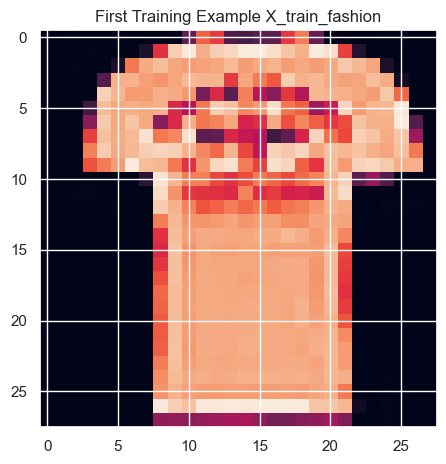

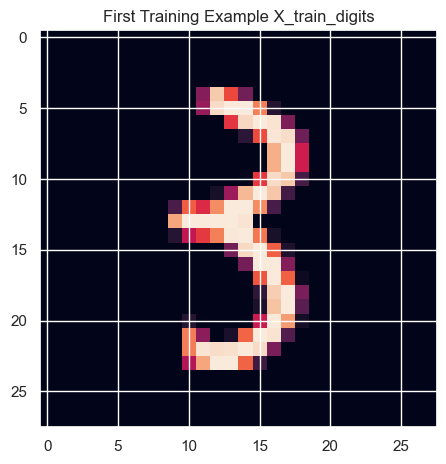

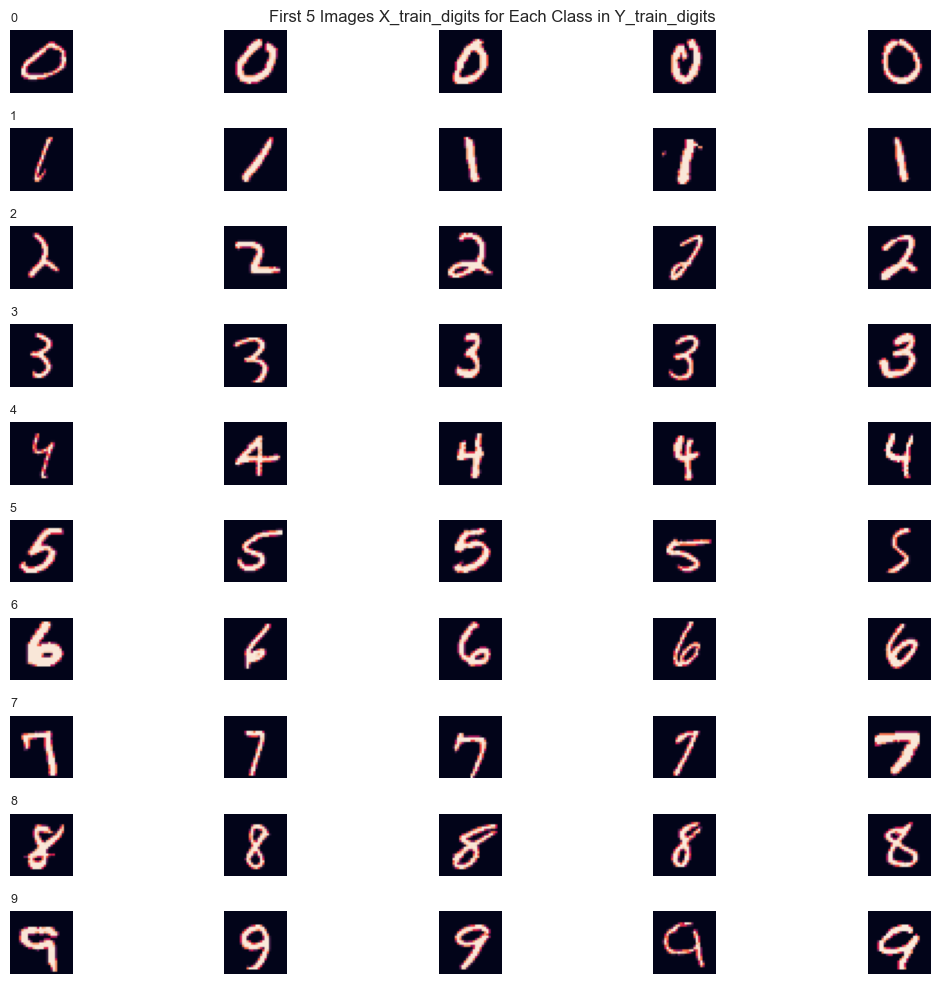

In [138]:
plt.imshow(X_train_fashion[0])
plt.title("First Training Example X_train_fashion")
plt.tight_layout()
plt.show()

plt.imshow(X_train_digits[0])
plt.title("First Training Example X_train_digits")
plt.tight_layout()
plt.show()

Y_train_digits_labels = np.unique(Y_train_digits)
fig, axes = plt.subplots(10,5, figsize=(10,10))
for class_id in range(10):
    class_image = np.where(Y_train_digits == class_id)[0][:5]
    for image_id, data_id in enumerate(class_image):
        ax = axes[class_id, image_id]
        ax.imshow(X_train_digits[data_id])
        ax.axis("off")
        if image_id ==0:
            ax.set_title(Y_train_digits_labels[class_id], loc = "left", fontsize=9)
axes[0][3].set_title("First 5 Images X_train_digits for Each Class in Y_train_digits", loc="right")
plt.tight_layout()    
plt.show()

### Step 4: Modeling

### <span style="color:chocolate">Exercise 2:</span> Define model (20 points)

1. Fill in the <span style="color:chocolate">build_model()</span> function below, including all the arguments listed in the function definition. Note: the activation function parameter is only for the the hidden layers; use the appropriate final classification function for the final layer.

In [139]:
def build_model(n_classes,
                hidden_layer_sizes=[],
                activation='relu',
                optimizer='SGD',
                learning_rate=0.01,
                metric='metric'):
    """Build a multi-class logistic regression model using Keras.

    Args:
    n_classes: Number of output classes in the dataset.
    hidden_layer_sizes: A list with the number of units in each hidden layer.
    activation: The activation function to use for the hidden layers.
    optimizer: The optimizer to use (SGD, Adam).
    learning_rate: The desired learning rate for the optimizer.
    metric: The desired metric.

    Returns:
    model: A tf.keras model (graph).
    """
    tf.keras.backend.clear_session()
    np.random.seed(0)
    tf.random.set_seed(0)

    # first layer: input
    input1 = tf.keras.layers.Input(shape=(28, 28), name='Input')
    # second layer: flatten
    # this layer has no params or weights to learn, it only reformats data
    x = tf.keras.layers.Flatten(name='Flatten')(input1) 
    
    for i in hidden_layer_sizes:
        x= layers.Dense(i, activation=activation)(x)

    outputs = layers.Dense(units=n_classes, activation='softmax')(x)
    model = keras.Model(inputs=input1, outputs=outputs)
    model.compile(
    optimizer=optimizer, 
    loss= "sparse_categorical_crossentropy",         #"binary_crossentropy",
    metrics=[metric]
    )

    return model

---
### Step 5: Experiments

You can now run a suite of experiments to see how the hyperparameters and layer sizes effect model performance. 

The <span style="color:chocolate">train_and_evaluate()</span> function below can be used to run experiments and retrieve results.

In [141]:
def train_and_evaluate(data='digits',
                       hidden_layer_sizes=[],
                       activation='tanh',
                       optimizer='Adam',
                       learning_rate=0.01,
                       metric='accuracy',
                       num_epochs=10):

  # Build the model.
    model = build_model(n_classes=10,
                      hidden_layer_sizes=hidden_layer_sizes,
                      activation=activation,
                      optimizer=optimizer,
                      metric=metric,
                      learning_rate=learning_rate)

  # Select the dataset.
    if data == 'digits':
        X_train = X_train_digits
        X_test = X_test_digits
        Y_train = Y_train_digits
        Y_test = Y_test_digits
    
    elif data == 'fashion':
        X_train = X_train_fashion
        X_test = X_test_fashion
        Y_train = Y_train_fashion
        Y_test = Y_test_fashion
    else:
        raise 'Unsupported dataset: %s' %data

  # Train the model.
    print('Training the', data, 'model...')
    history = model.fit(
        x=X_train,
        y=Y_train,
        epochs=num_epochs,
        batch_size=64,
        validation_split=0.1,
        verbose=0)

    # Retrieve the training metrics (after each train epoch) and the final validation
    # accuracy.
    train_accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']
    #plt.plot(train_accuracy, label='train_accuracy')
    #plt.plot(val_accuracy, label='validation accuracy')
    #plt.xticks(range(num_epochs))
    #plt.xlabel('Train epochs')
    #plt.legend()
    #plt.show()
    #plt.ioff()
    
    print('Training accuracy: %1.4f' %train_accuracy[-1])
    print('Validation accuracy: %1.4f' %val_accuracy[-1])
    
    model_details = [data, hidden_layer_sizes, activation, optimizer, learning_rate, model.count_params(), train_accuracy[-1], val_accuracy[-1]]

    return model, model_details


# run the function
model_1, details_list_1 = train_and_evaluate(hidden_layer_sizes=[2,2],optimizer='Adam')

Training the digits model...
Training accuracy: 0.5512
Validation accuracy: 0.5667


### <span style="color:chocolate">Exercise 3:</span> Ablation study (50 points)

1. Conduct experiments and record the training and validation set accuracy results in the table below. You may extend the table for additional experiments as needed.
2. Report the hyperparameter values for your preferred architecture configuration.
3. Run the model once more using your preferred hyperparameter configuration.

Data | Hidden sizes | Activation| Optimizer | Learning rate | #Parameters | Training accuracy| Validation accuracy
-|-|-|-|-|-|-|-
 digits | [] | tanh | SGD |0.01| 7850 | |
 digits | [] | relu | SGD |0.01| 7850 | |
 digits | [] | relu | Adam |0.01| 7850 | |
 digits | [128] | relu | Adam |0.01| 101770 | |
 digits | [256, 128] | relu | Adam |0.01| 235146 | |
-|-|-|-|-|-|-|-
 fashion | [] | tanh | SGD |0.01| 7850 | |
 fashion | [] | relu | SGD |0.01| 7850 | |
 fashion | [] | relu | Adam |0.01| 7850 | |
 fashion | [128] | relu | Adam |0.01| 101770 | |
 fashion | [256, 128] | relu | Adam |0.01| 235146 | |

In [151]:
print(f"I will recreate the table using a loop and pandas below with models I created in experiments.")

I will recreate the table using a loop and pandas below with models I created in experiments.


In [148]:
model_2, details_list_2 = train_and_evaluate(hidden_layer_sizes=[3,3,3], activation='relu', optimizer='Adam')
model_3, details_list_3 = train_and_evaluate(hidden_layer_sizes=[4,4,4,3,2], activation='relu')
model_4, details_list_4 = train_and_evaluate(hidden_layer_sizes=[50], learning_rate = 0.001, activation='relu', optimizer='SGD')
model_5, details_list_5 = train_and_evaluate( hidden_layer_sizes=[90], activation='tanh', optimizer='Adam')

model_6, details_list_6 = train_and_evaluate(data='fashion', hidden_layer_sizes=[2,2], activation='tanh', optimizer='SGD')
model_7, details_list_7 = train_and_evaluate(data='fashion', hidden_layer_sizes=[5,5,4,3], activation='relu', optimizer='Adam')
model_8, details_list_8 = train_and_evaluate(data='fashion', hidden_layer_sizes=[50], activation='tanh', optimizer='Adam')
model_9, details_list_9 = train_and_evaluate(data='fashion', hidden_layer_sizes=[90], activation='relu', optimizer='Adam')
model_10, details_list_10 = train_and_evaluate(data='fashion', hidden_layer_sizes=[90,90,50], activation='relu', optimizer='Adam')


Training the digits model...
Training accuracy: 0.3134
Validation accuracy: 0.3603
Training the digits model...
Training accuracy: 0.2620
Validation accuracy: 0.2810
Training the digits model...
Training accuracy: 0.9137
Validation accuracy: 0.9155
Training the digits model...
Training accuracy: 0.9935
Validation accuracy: 0.9735
Training the fashion model...
Training accuracy: 0.4818
Validation accuracy: 0.4928
Training the fashion model...
Training accuracy: 0.7162
Validation accuracy: 0.7082
Training the fashion model...
Training accuracy: 0.9019
Validation accuracy: 0.8720
Training the fashion model...
Training accuracy: 0.8542
Validation accuracy: 0.8348
Training the fashion model...
Training accuracy: 0.5178
Validation accuracy: 0.4683


In [150]:
model_details=[]
model_details.append(details_list_1)
model_details.append(details_list_2)
model_details.append(details_list_3)
model_details.append(details_list_4)
model_details.append(details_list_5)
model_details.append(details_list_6)
model_details.append(details_list_7)
model_details.append(details_list_8)
model_details.append(details_list_9)
model_details.append(details_list_10)

data = []
for i in range(len(model_details)):
    row_data = {"Data": [model_details[i][0]], "Hidden sizes": [model_details[i][1]], "Activation": [model_details[i][2]], 
        "Optimizer": [model_details[i][3]], "Learning rate": [model_details[i][4]], 
        "#Parameters": [model_details[i][5]], "Training Accuracy": [model_details[i][6]], 
        "Validation Accuracy": [model_details[i][7]]}
    i += 1
    data.append(row_data)
print("The final models I will proceed with are models 4 for digits and 8 for fashion. They have the highest accuracy scores for \n \
    validation and test data sets out of these and other model experiments I ran.")
table=pd.DataFrame.from_dict(data)
table

The final models I will proceed with are models 4 for digits and 8 for fashion. They have the highest accuracy scores for 
     validation and test data sets out of these and other model experiments I ran.


,Data,Hidden sizes,Activation,Optimizer,Learning rate,#Parameters,Training Accuracy,Validation Accuracy
0,[digits],"[[2, 2]]",[tanh],[Adam],[0.01],[1606],[0.5512222051620483],[0.5666666626930237]
1,[digits],"[[3, 3, 3]]",[relu],[Adam],[0.01],[2419],[0.3134259283542633],[0.36033332347869873]
2,[digits],"[[4, 4, 4, 3, 2]]",[relu],[Adam],[0.01],[3233],[0.2620370388031006],[0.2809999883174896]
3,[digits],[[50]],[relu],[SGD],[0.001],[39760],[0.9136852025985718],[0.9154999852180481]
4,[digits],[[90]],[tanh],[Adam],[0.01],[71560],[0.9935370087623596],[0.9735000133514404]
5,[fashion],"[[2, 2]]",[tanh],[SGD],[0.01],[1606],[0.48177778720855713],[0.49283334612846375]
6,[fashion],"[[5, 5, 4, 3]]",[relu],[Adam],[0.01],[4034],[0.7162036895751953],[0.7081666588783264]
7,[fashion],[[50]],[tanh],[Adam],[0.01],[39760],[0.9018703699111938],[0.871999979019165]
8,[fashion],[[90]],[relu],[Adam],[0.01],[71560],[0.854185163974762],[0.8348333239555359]
9,[fashion],"[[90, 90, 50]]",[relu],[Adam],[0.01],[83900],[0.5177962779998779],[0.46833333373069763]


---
### Step 6: Evaluation and Generalization

### <span style="color:chocolate">Exercise 4:</span> Compute metrics (25 points)

Now that you've determined the optimal set of hyperparameters, it's time to evaluate your optimized model on the test data to gauge its performance in real-world scenarios, commonly known as inference.

1. Calculate accuracy on both train and test datasets. Note: you will need to convert the vector of predicted probabilities to a class label using the argmax operation. Hint: You can utilize the <span style="color:chocolate">model.predict()</span> method provided by tf.keras and the <span style="color:chocolate">np.max()</span> method available in NumPy; or you can use the <span style="color:chocolate">model.evaluare()</span> method provided by tf.keras directly.

2. Does the model demonstrate strong generalization capabilities? Provide an explanation based on your accuracy observations.

In [147]:
### print accuracy for training
y_train_pred_digits = model_4.predict(x=X_train_digits)
y_train_pred_fashion = model_9.predict(x=X_train_fashion)

# set predicted label based on highest probability
y_train_maxpred_digits =  np.argmax(y_train_pred_digits, axis=1)
y_train_maxpred_fashion =  np.argmax(y_train_pred_fashion, axis=1)

print('Train, misclassified examples digits: %d' % (Y_train_digits != y_train_maxpred_digits).sum())
error_train_digits = (Y_train_digits != y_train_maxpred_digits).sum()/len(y_train_maxpred_digits)
print('Train, prediction accuracy digits: %.3f'% (1-error_train_digits))

print('Train, misclassified examples fashion: %d' % (Y_train_fashion != y_train_maxpred_fashion).sum())
error_train_fashion = (Y_train_fashion != y_train_maxpred_fashion).sum()/len(y_train_maxpred_fashion)
print('Train, prediction accuracy fashion: %.3f'% (1-error_train_fashion))

### print accuracy for test
y_test_pred_digits = model_4.predict(x=X_test_digits)
y_test_pred_fashion = model_9.predict(x=X_test_fashion)

# set predicted label based on highest probability
y_test_maxpred_digits =  np.argmax(y_test_pred_digits, axis=1)
y_test_maxpred_fashion =  np.argmax(y_test_pred_fashion, axis=1)

print('Test, misclassified examples digits: %d' % (Y_test_digits != y_test_maxpred_digits).sum())
error_test_digits = (Y_test_digits != y_test_maxpred_digits).sum()/len(y_test_maxpred_digits)
print('Test, prediction accuracy digits: %.3f'% (1-error_test_digits))

print('Test, misclassified examples fashion: %d' % (Y_test_fashion != y_test_maxpred_fashion).sum())
error_test_fashion = (Y_test_fashion != y_test_maxpred_fashion).sum()/len(y_test_maxpred_fashion)
print('Test, prediction accuracy fashion: %.3f'% (1-error_test_fashion))

print(f"Based on the difference between training and test prediction accuracy, which is the number of correct predictions out of \n \
      total (total predictions made by our model), the generalization is pretty good for both models because the difference \n \
      between train prediction accuracy and test prediction accuracy is very small. For my digits model, the difference \n \
        between train and test accuracy is 0.003 and for fashion model the difference is 0.001. So these models show strong \n \
            generalization capabilities and have good prediction accuracy scores.")

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Train, misclassified examples digits: 5131
Train, prediction accuracy digits: 0.914
Train, misclassified examples fashion: 8418
Train, prediction accuracy fashion: 0.860
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Test, misclassified examples digits: 828
Test, prediction accuracy digits: 0.917
Test, misclassified examples fashion: 1603
Test, prediction accuracy fashion: 0.840
Based on the difference between training and test prediction accuracy, which is the number of correct predictions out of 
       total (total predictions made by our model), the generalization is pretty good for both models because the difference 
       between train prediction accuracy and test prediction accuracy is very small. For my digits model, the difference 
         between train and test accuracy is 0.003 and for fashion model the difference is 0.001. So these models show strong 
 